In [4]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import sklearn
import tensorflow as tf

In [5]:
# a )
l_x = []

for i in range(10000):
    x = random.random()
    l_x.append(x)

In [6]:
def f(x): #Def the function sqrt(1 + x)
    return np.sqrt(1 + x)

d = {}
y = []

for i in range(10000):
    d[l_x[i]] = f(l_x[i])
    y.append(f(l_x[i]))

ser = pd.Series(d)

In [66]:
%%time
## b)
x_m = sum(l_x)/10000
y_m = ser.mean()

k = 0
z = 0
for i in d.keys():
    k = k + (d[i] * i - y_m * i) 

for i in d.keys():
    z = z +( (i**2) - x_m * i)
    
w = k / z
b = y_m - w*x_m
w,b

Wall time: 29 ms


(0.4120585513779509, 1.0128702345694411)

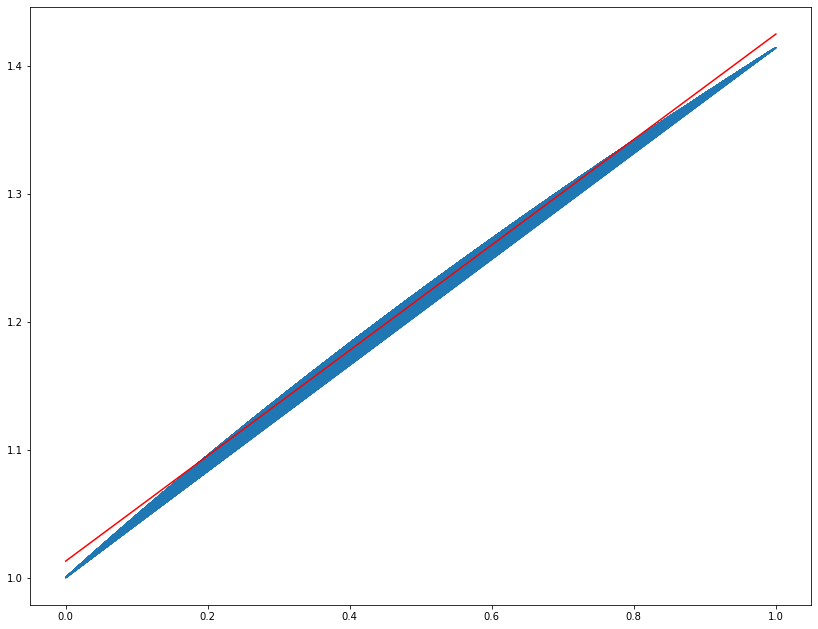

In [13]:
#just for visualisation
plt.figure(figsize = (14, 11))
plt.plot(l_x, ser);
x = np.linspace(0,1,1000)
plt.plot(x, w*x + b,color ='r');


In [67]:
%%time
#The Sklearn method c)
X = pd.Series(l_x)
Y = pd.Series(y)
X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(X, Y, test_size = 0.25, random_state = 5)

regression = LinearRegression()
X_train = np.array(X_train).reshape(7500, 1)
regression.fit(X_train, Y_train)


# regression = LinearRegression()
# X = np.array(X).reshape(10000, 1)
# regression.fit(X, Y)
# This is also a correct solution which uses the whole dataset to train the one before uses only the 75% of the dataset

print(regression.coef_, regression.intercept_)
#finish sklearn

[0.41197727] 1.0128544550151408
Wall time: 70.1 ms


In [68]:
%%time
#Gradient descend own algorithm  d)

x_n = np.array((5, 2), dtype = 'float64')       

def grad(args): 
    
    "Finding the Gradient of  g(w, b)."
    
    d_w = 0
    d_b = 0
    for i in range(10000):
        d_w += 2 * l_x[i] * (args[0] * l_x[i] + args[1] - y[i]) / 10000

    for i in range(10000):
        d_b += 2 * (args[0] * l_x[i] + args[1] - y[i]) / 10000
        
    return np.array((d_w, d_b),dtype = 'float64')



def grad_des(args, learning_r):
    
    """Gradient descent algirithm.
args : the random points from which you need to find the local min point.
learning_r : the learning rate of gradient descent."""
    
    global x_n , alpha
    for _ in range(500):
        x_n = x_n - ( learning_r * grad(x_n) )

    return x_n

grad_des(x_n, 0.15)

# optimal solution (0.4116818334332945, 1.0130523754921428)


Wall time: 27 s


array([0.41219033, 1.01280034])

In [70]:
%%time
# tensoflow grad_descend e)

def grad_tensor(X, Y, max_iter, eps, alpha):
    ones = np.ones((10000,1))
    X = np.array(l_x).reshape(10000, 1)
    Y = np.array(y).reshape(10000,1)
    X = np.concatenate((X, ones),  axis = 1 )
    X = tf.convert_to_tensor(X , dtype = 'float32')
    Y = tf.convert_to_tensor(Y , dtype = 'float32')

    w = tf.Variable(tf.random.uniform(shape=(2, 1), minval=-1, maxval=1), 
                                 dtype=tf.float32)
    
    diff = 1e6
    i = 0
    while (i < max_iter) and (diff > eps):
        w_old = w.numpy()
        with tf.GradientTape() as tape:
            pred = tf.matmul(X, w)
            model_loss = tf.reduce_sum((pred - Y) ** 2) / 10000
            


        grad = tape.gradient(model_loss,w)
        w.assign_sub(grad * alpha) 
        w_new = w.numpy()
        diff = np.linalg.norm(w_new - w_old)
        max_iter += 1


    return w.numpy()

grad_tensor(l_x, y, 500, 1e-6, 0.15)


    

Wall time: 1.19 s


array([[0.41210145],
       [1.0128474 ]], dtype=float32)

In [71]:
%%time
## SGD
def SGD(x_train, y_train, alfa, n_epoch, eps, init = [5,2]):
    a = np.ones((10000,1))
    x_arr = np.concatenate([np.array(x_train).reshape((10000,1)), a],axis = 1)
    w = np.array(init)
    diff = 1e6
    j = 0
    while (j < n_epoch) and (diff > eps):
        w_old = w
        for i in range(len(y_train)):
            w = w - alfa * (np.array((2 * x_train[i] * (w @ x_arr[i] - y_train[i]) , 2 * (w @ x_arr[i] - y_train[i]))) / 10000)
        w_new = w
        diff = np.linalg.norm(w_old - w_new)
        j += 1
    return w , j

SGD(l_x, y, n_epoch = 500, eps = 1e-6, alfa = 0.15)           

Wall time: 1min 28s


(array([0.41220604, 1.01278853]), 500)

In [72]:
%%time
## Batch GD
def SGD_minBatch(x_train, y_train, alfa, batch, n_epoch, eps, init = [5,2]):
    a = np.ones((10000,1))
    x_arr = np.concatenate([np.array(x_train).reshape((10000,1)), a],axis = 1)
    w = np.array(init)
    diff = 1e6
    j = 0
    while (j < n_epoch) and (diff > eps):
        w_old = w
        for i in range(int (len(y) / batch)):
            for k in range((i - 1) * (batch + 1), i * batch):
                grad = 0
                grad = grad + (np.array((2 * x_train[k] * (w @ x_arr[k] - y_train[k]) , 2 * (w @ x_arr[k] - y_train[k]))) / batch)
            w = w - alfa * grad
        w_new = w
        diff = np.linalg.norm(w_old - w_new)
        j += 1
    return w , j

SGD_minBatch(l_x, y, batch = 100, n_epoch = 500, eps = 1e-6, alfa = 0.15)

Wall time: 39.4 s


(array([0.41344039, 1.01247894]), 500)